# **World Population Data Visualization**

## SkillCraft Technology-Data Science Internship

## Task 01

This project visualizes population data obtained from the World Bank.
A bar chart is used to compare the populations of the top 10 most populous countries.

### Dataset

World Bank - Population, total (SP.POP.TOTL)

### Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab

In [20]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
url = "https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&per_page=20000"

response = requests.get(url)
json_data = response.json()

records = json_data[1]

df = pd.DataFrame(records)

df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.POP.TOTL', 'value': 'Population, to...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,788844284.0,,,0
1,"{'id': 'SP.POP.TOTL', 'value': 'Population, to...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,769280888.0,,,0
2,"{'id': 'SP.POP.TOTL', 'value': 'Population, to...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,750491370.0,,,0
3,"{'id': 'SP.POP.TOTL', 'value': 'Population, to...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,731821393.0,,,0
4,"{'id': 'SP.POP.TOTL', 'value': 'Population, to...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,713090928.0,,,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17490 entries, 0 to 17489
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        17490 non-null  object 
 1   country          17490 non-null  object 
 2   countryiso3code  17490 non-null  object 
 3   date             17490 non-null  object 
 4   value            17394 non-null  float64
 5   unit             17490 non-null  object 
 6   obs_status       17490 non-null  object 
 7   decimal          17490 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 1.1+ MB


In [25]:
df.shape


(17490, 8)

In [26]:
df["country_name"] = df["country"].apply(
    lambda x: x["value"] if isinstance(x, dict) else x
)

df[["country_name", "countryiso3code", "date", "value"]].head()

,country_name,countryiso3code,date,value
0,Africa Eastern and Southern,AFE,2025,788844284.0
1,Africa Eastern and Southern,AFE,2024,769280888.0
2,Africa Eastern and Southern,AFE,2023,750491370.0
3,Africa Eastern and Southern,AFE,2022,731821393.0
4,Africa Eastern and Southern,AFE,2021,713090928.0


In [27]:
df["date"] = pd.to_numeric(df["date"], errors="coerce")

In [28]:
df = df.dropna(subset=["value"])

In [29]:
latest_year = int(df["date"].max())

print("Latest available year:", latest_year)

Latest available year: 2025


In [30]:
countries_url = "https://api.worldbank.org/v2/country?format=json&per_page=400"

countries_response = requests.get(countries_url)
countries_data = countries_response.json()[1]

countries_data[:2]

[{'id': 'ABW',
  'iso2Code': 'AW',
  'name': 'Aruba',
  'region': {'id': 'LCN',
   'iso2code': 'ZJ',
   'value': 'Latin America & Caribbean '},
  'adminregion': {'id': '', 'iso2code': '', 'value': ''},
  'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'},
  'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'},
  'capitalCity': 'Oranjestad',
  'longitude': '-70.0167',
  'latitude': '12.5167'},
 {'id': 'AFE',
  'iso2Code': 'ZH',
  'name': 'Africa Eastern and Southern',
  'region': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'},
  'adminregion': {'id': '', 'iso2code': '', 'value': ''},
  'incomeLevel': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'},
  'lendingType': {'id': '', 'iso2code': '', 'value': 'Aggregates'},
  'capitalCity': '',
  'longitude': '',
  'latitude': ''}]

In [32]:
country_codes = [
    c["id"]
    for c in countries_data
    if c["region"]["value"] != "Aggregates"
]

print("Number of actual countries:", len(country_codes))

Number of actual countries: 217


In [33]:
latest_data = df[df["date"] == latest_year].copy()

print("Rows in latest year:", len(latest_data))

Rows in latest year: 264


In [34]:
latest_data = latest_data[
    latest_data["countryiso3code"].isin(country_codes)
].copy()

print("Actual countries in latest year:", len(latest_data))

Actual countries in latest year: 217


In [35]:
top10 = latest_data.sort_values(
    by="value",
    ascending=False
).head(10)

top10[[
    "country_name",
    "countryiso3code",
    "date",
    "value"
]]

,country_name,countryiso3code,date,value
9042,India,IND,2025,1.463866e+09
5874,China,CHN,2025,1.406585e+09
16764,United States,USA,2025,3.417849e+08
9108,Indonesia,IDN,2025,2.857212e+08
13002,Pakistan,PAK,2025,2.552196e+08
12672,Nigeria,NGA,2025,2.375278e+08
4884,Brazil,BRA,2025,2.128124e+08
4158,Bangladesh,BGD,2025,1.756869e+08
13794,Russian Federation,RUS,2025,1.435133e+08
7392,Ethiopia,ETH,2025,1.354721e+08


In [36]:
top10["population_millions"] = (
    top10["value"] / 1_000_000
)

top10[[
    "country_name",
    "population_millions"
]]


,country_name,population_millions
9042,India,1463.865525
5874,China,1406.585000
16764,United States,341.784857
9108,Indonesia,285.721236
13002,Pakistan,255.219554
12672,Nigeria,237.527782
4884,Brazil,212.812405
4158,Bangladesh,175.686899
13794,Russian Federation,143.513328
7392,Ethiopia,135.472051


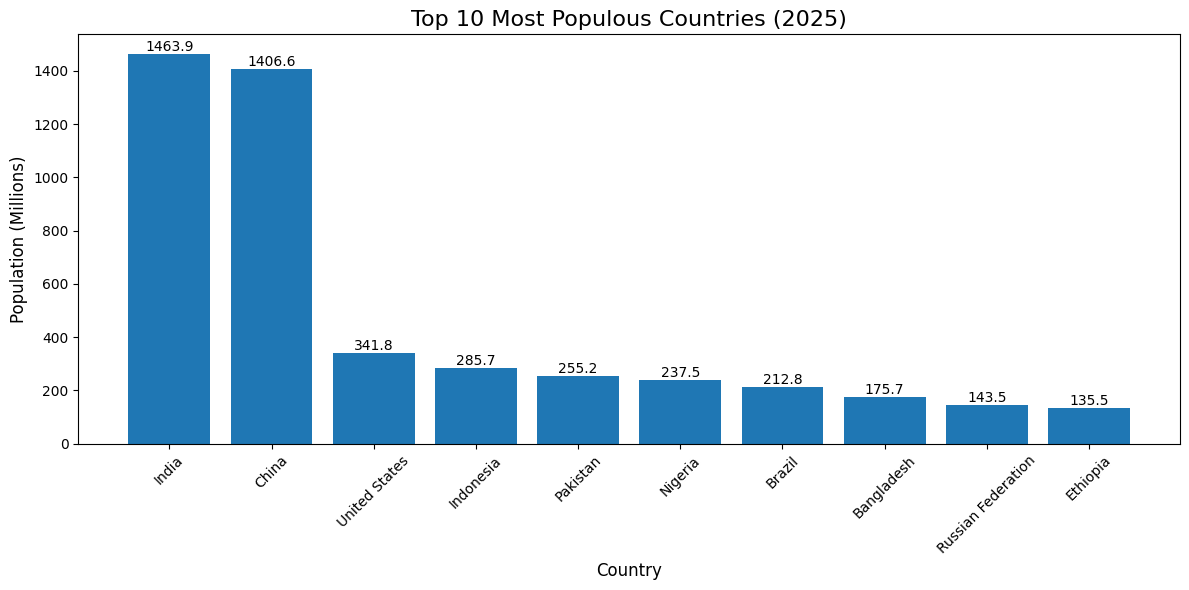

In [37]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    top10["country_name"],
    top10["population_millions"]
)

plt.title(
    f"Top 10 Most Populous Countries ({latest_year})",
    fontsize=16
)

plt.xlabel("Country", fontsize=12)
plt.ylabel("Population (Millions)", fontsize=12)

plt.xticks(rotation=45)

# Add population values above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

## Observations

1. India has the highest population among the top 10 countries, with approximately 1,463.9 million people.

2. China has the second-highest population, with approximately 1,406.6 million people.

3. There is a significant difference between the populations of India and China and those of the remaining countries.

4. The United States ranks third with approximately 341.8 million people.

5. Indonesia, Pakistan, Nigeria, and Brazil have populations between approximately 200 and 300 million.

6. Bangladesh, the Russian Federation, and Ethiopia have populations below 200 million among the selected top 10 countries.

7. The bar chart clearly shows the large variation in population size among the world's most populous countries.

8. The visualization makes it easier to compare population sizes across countries.

## Conclusion

The visualization shows that population is highly concentrated among a few countries, particularly India and China. A bar chart provides an effective way to compare population sizes and identify differences between countries.